# Лабораторная работа №4

**Задание 1. Загрузить датасет написать код разбиения на обучающую и проверочную выборки, а также воспользоваться встроенными методами библиотеки sklearn.**
1. Датасет: 09_Energy_and_Water_Data_Disclosure_for_Local_Law_84_2017__Data_for_Calendar_Year_2016_.csv
2. Скоринг энергопотребления зданий в Нью-Йорке.


**Импорты**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

In [2]:
df = pd.read_csv('09_Energy_and_Water_Data_Disclosure_for_Local_Law_84_2017__Data_for_Calendar_Year_2016_.csv')
print(f"Загружено: {df.shape}")
display(df.head())
df.info()
target = 'Site EUI (kBtu/ft²)'
features = ['Number of Buildings - Self-reported', 'Property GFA - Self-Reported (ft²)', 
            'Weather Normalized Site Electricity (kWh)']

for col in features + [target]:
    df[col] = pd.to_numeric(df[col], errors='coerce')  
df_clean = df.dropna(subset=features + [target])      
print(f"После очистки: {df_clean.shape}")
X = df_clean[features]
y = df_clean[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      
    random_state=42    
)
print(f"\nОбучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Загружено: (11746, 60)


,Order,Property Id,Property Name,Parent Property Id,Parent Property Name,BBL - 10 digits,"NYC Borough, Block and Lot (BBL) self-reported",NYC Building Identification Number (BIN),Address 1 (self-reported),Address 2,...,Source EUI (kBtu/ft²),Release Date,Water Required?,DOF Benchmarking Submission Status,Latitude,Longitude,Community Board,Council District,Census Tract,NTA
0,1,13286,201/205,13286,201/205,1013160001,1013160001,1037549,201/205 East 42nd st.,Not Available,...,619.4,05/01/2017 05:32:03 PM,No,In Compliance,40.750791,-73.973963,6.0,4.0,88.0,Turtle Bay-East Midtown ...
1,2,28400,NYP Columbia (West Campus),28400,NYP Columbia (West Campus),1021380040,1-02138-0040,1084198; 1084387;1084385; 1084386; 1084388; 10...,622 168th Street,Not Available,...,404.3,04/27/2017 11:23:27 AM,No,In Compliance,40.841402,-73.942568,12.0,10.0,251.0,Washington Heights South ...
2,3,4778226,MSCHoNY North,28400,NYP Columbia (West Campus),1021380030,1-02138-0030,1063380,3975 Broadway,Not Available,...,Not Available,04/27/2017 11:23:27 AM,No,In Compliance,40.840427,-73.940249,12.0,10.0,251.0,Washington Heights South ...
3,4,4778267,Herbert Irving Pavilion & Millstein Hospital,28400,NYP Columbia (West Campus),1021390001,1-02139-0001,1087281; 1076746,161 Fort Washington Ave,177 Fort Washington Ave,...,Not Available,04/27/2017 11:23:27 AM,No,In Compliance,40.840746,-73.942854,12.0,10.0,255.0,Washington Heights South ...
4,5,4778288,Neuro Institute,28400,NYP Columbia (West Campus),1021390085,1-02139-0085,1063403,710 West 168th Street,Not Available,...,Not Available,04/27/2017 11:23:27 AM,No,In Compliance,40.841559,-73.942528,12.0,10.0,255.0,Washington Heights South ...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11746 entries, 0 to 11745
Data columns (total 60 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   Order                                                       11746 non-null  int64  
 1   Property Id                                                 11746 non-null  int64  
 2   Property Name                                               11746 non-null  object 
 3   Parent Property Id                                          11746 non-null  object 
 4   Parent Property Name                                        11746 non-null  object 
 5   BBL - 10 digits                                             11735 non-null  object 
 6   NYC Borough, Block and Lot (BBL) self-reported              11746 non-null  object 
 7   NYC Building Identification Number (BIN)                    11746 non-null  object 
 

**Задание 2. Загрузить датасет, проанализировать признаки на нормальность и нормализовать, воспользоваться встроенными методами библиотеки sklearn.**
1. Датасет: 09_Energy_and_Water_Data_Disclosure_for_Local_Law_84_2017__Data_for_Calendar_Year_2016_.csv
2. Скоринг энергопотребления зданий в Нью-Йорке.


Данные загружены: кол-во строк 10954 

Анализ признаков на нормальность

Number of Buildings - Self-reported:
  Коэффициент асимметрии: 27.362
  Тест Шапиро-Уилка: p-value = 0.000000
  - Сильная правосторонняя асимметрия
  - Распределение не нормальное (p < 0.05)

Property GFA - Self-Reported (ft²):
  Коэффициент асимметрии: 18.068
  Тест Шапиро-Уилка: p-value = 0.000000
  - Сильная правосторонняя асимметрия
  - Распределение не нормальное (p < 0.05)

Weather Normalized Site Electricity (kWh):
  Коэффициент асимметрии: 37.131
  Тест Шапиро-Уилка: p-value = 0.000000
  - Сильная правосторонняя асимметрия
  - Распределение не нормальное (p < 0.05)


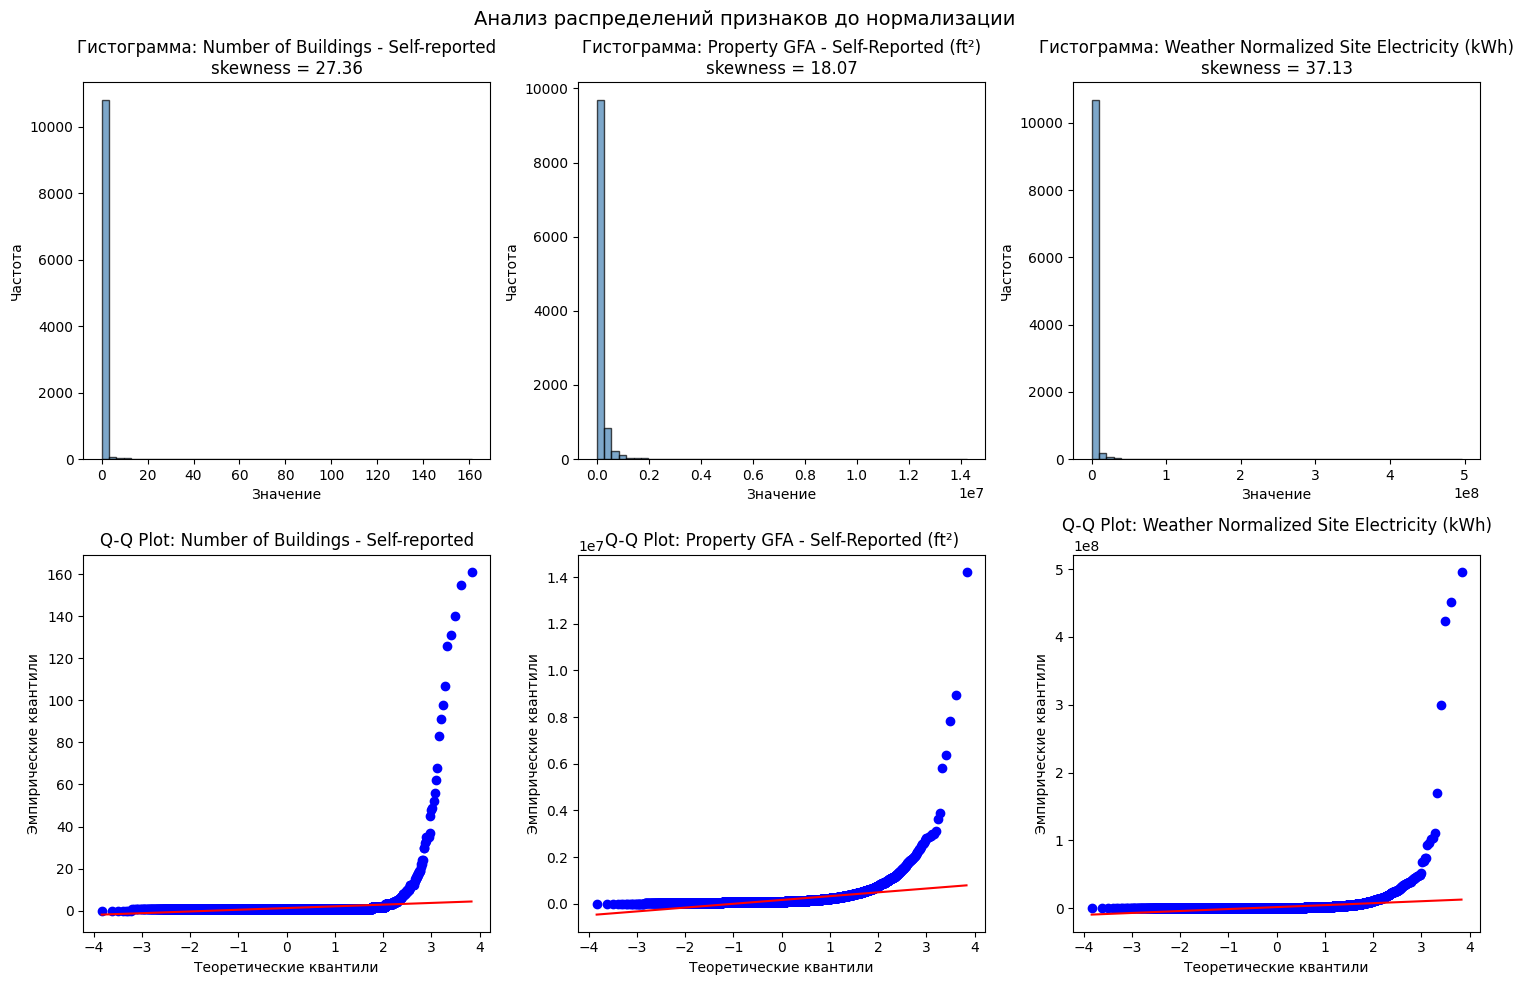

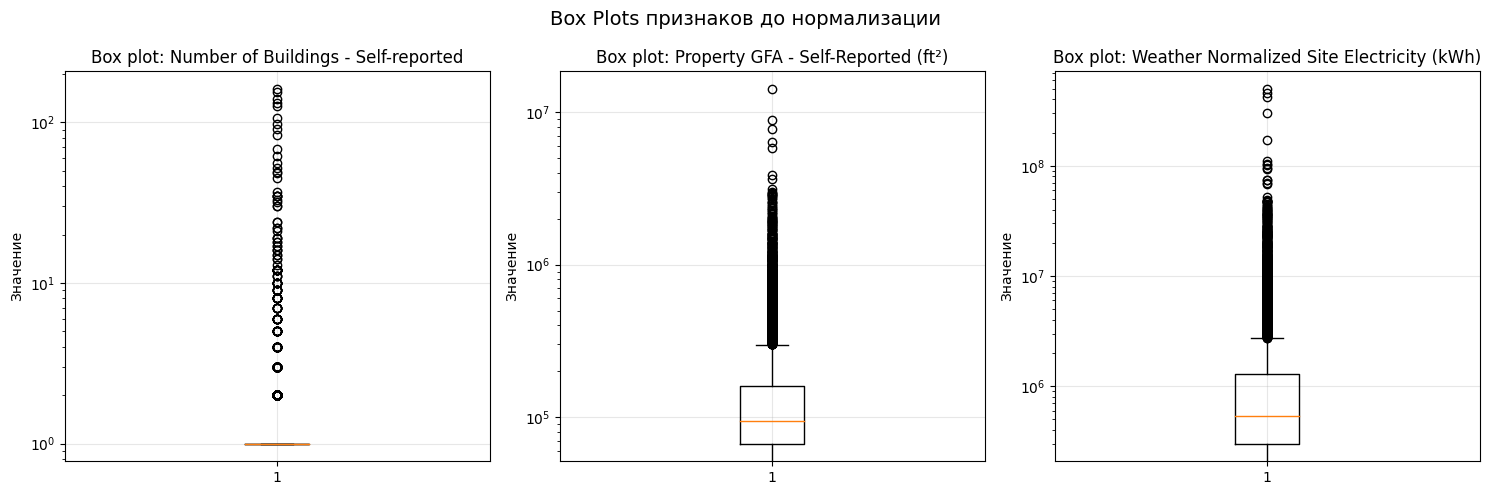

Нормализация признаков (sklearn)

1. StandardScaler:
   Среднее после: [ 0. -0.  0.]
   Дисперсия после: [1. 1. 1.]

2. MinMaxScaler:
   Минимум: [0. 0. 0.]
   Максимум: [1. 1. 1.]

3. RobustScaler:
   Медиана после: [0. 0. 0.]


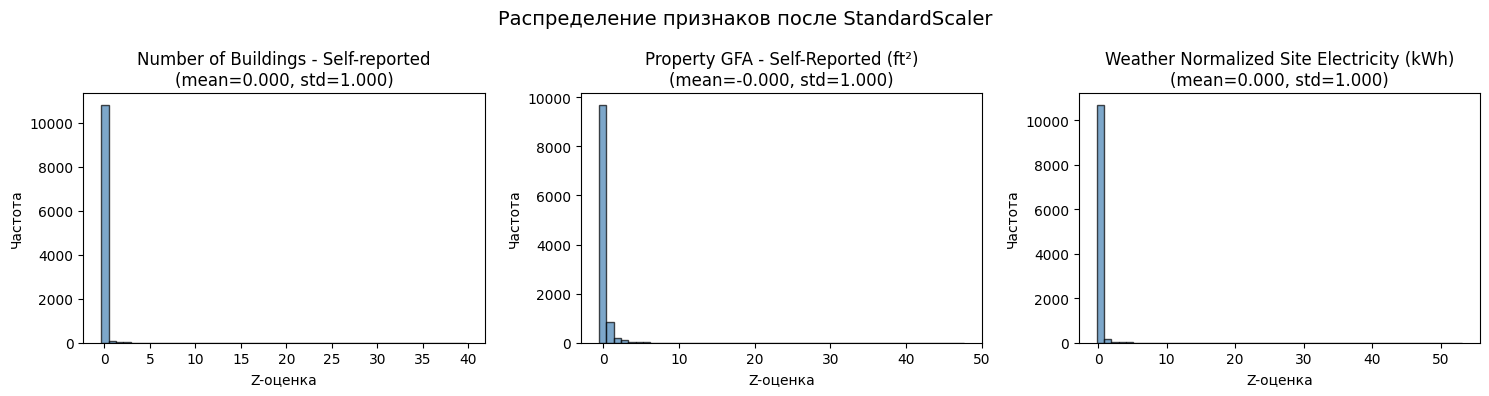

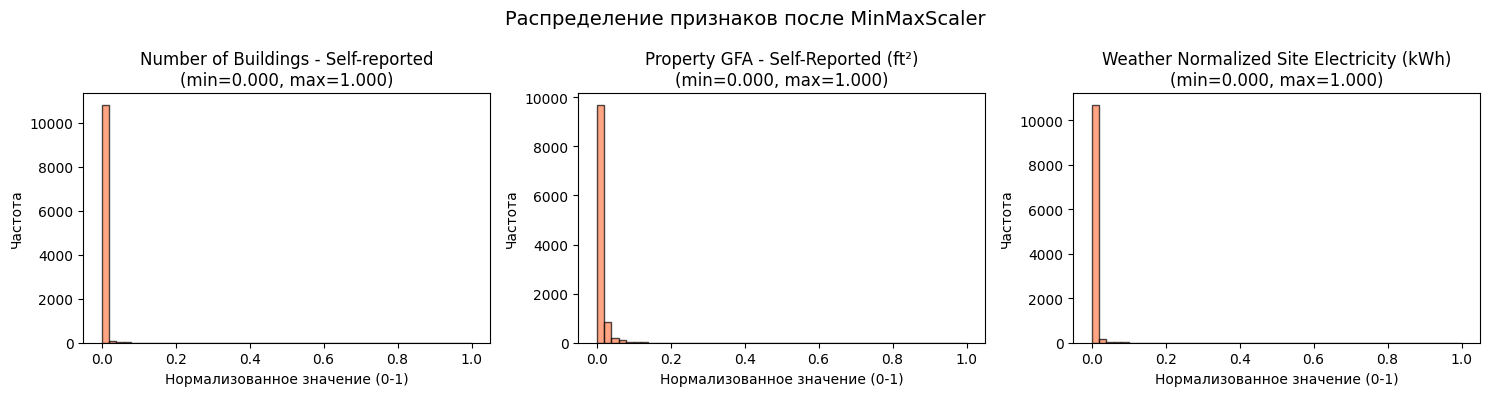

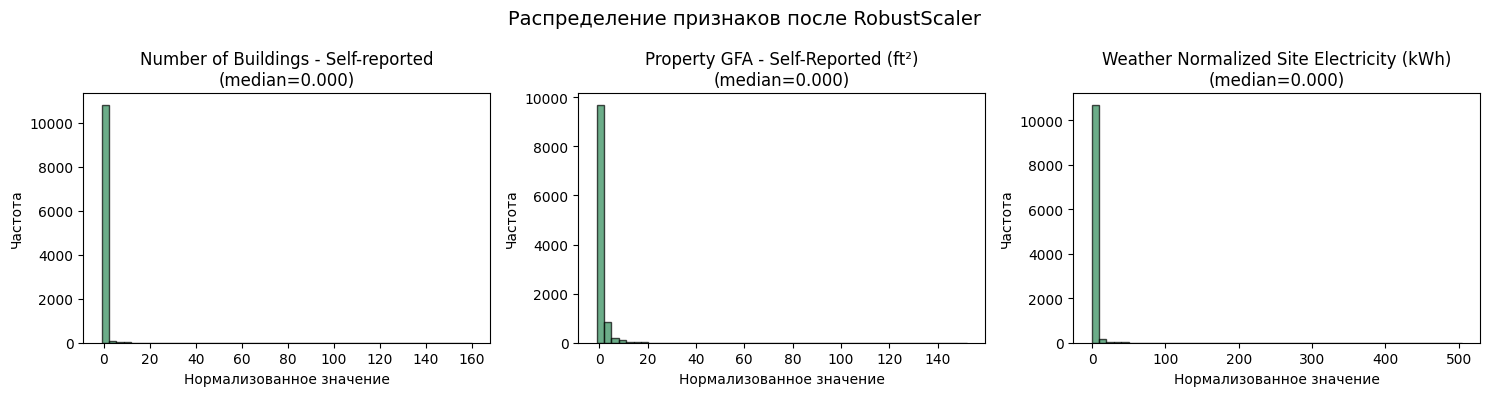

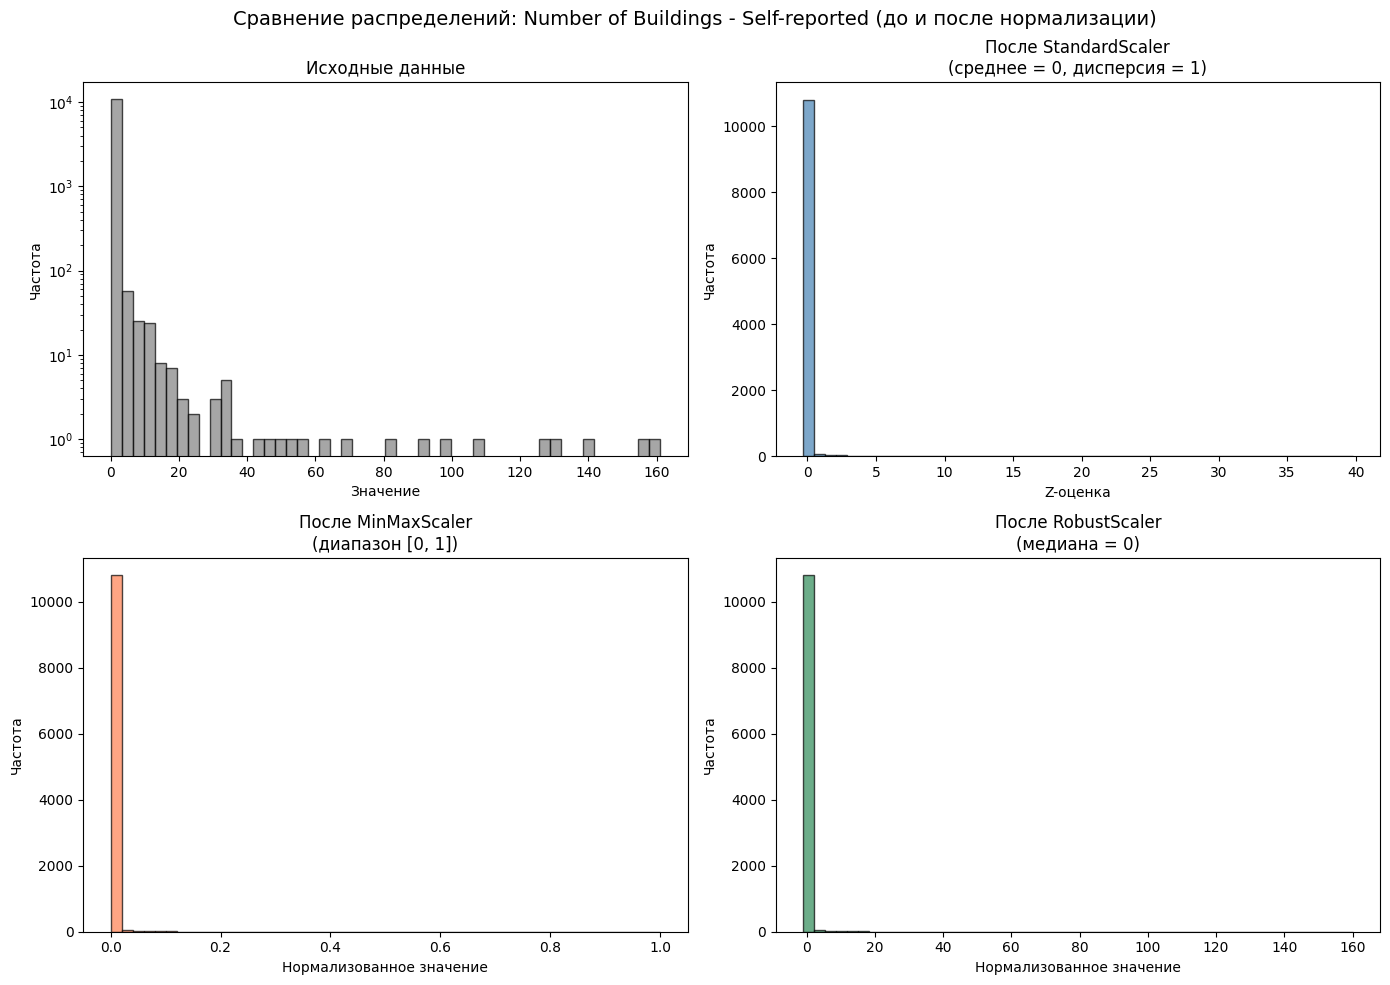

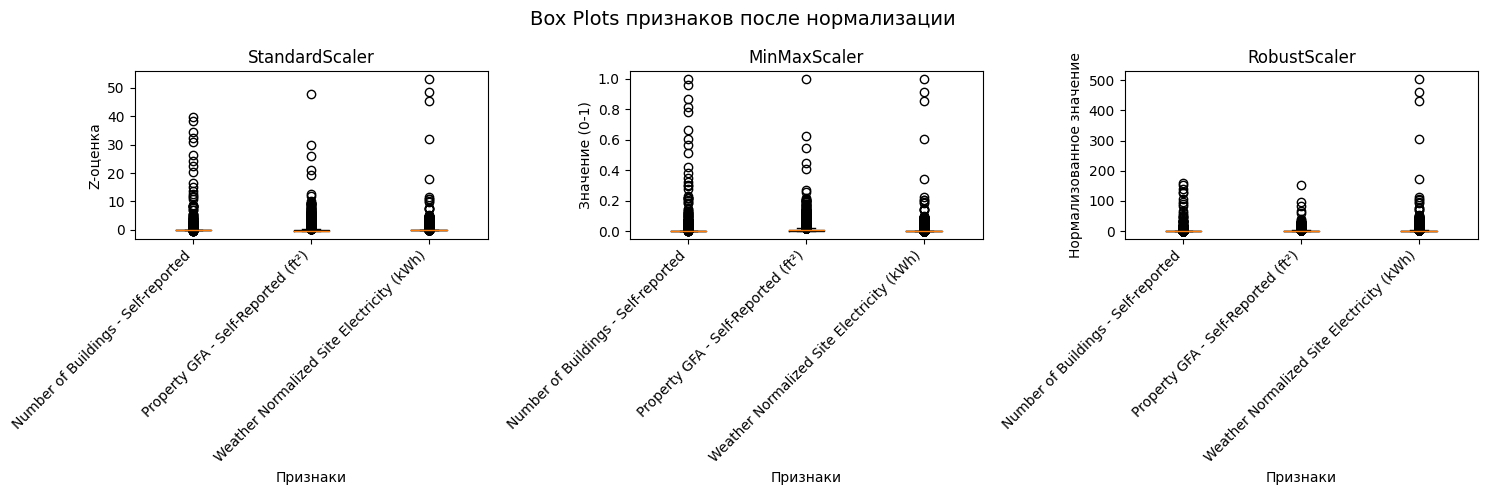

In [3]:
df = pd.read_csv('09_Energy_and_Water_Data_Disclosure_for_Local_Law_84_2017__Data_for_Calendar_Year_2016_.csv')
target = 'Site EUI (kBtu/ft²)'
features = ['Number of Buildings - Self-reported', 'Property GFA - Self-Reported (ft²)', 
            'Weather Normalized Site Electricity (kWh)']
for col in features + [target]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_clean = df.dropna(subset=features + [target])
print(f"Данные загружены: кол-во строк {df_clean.shape[0]} \n")
print("Анализ признаков на нормальность")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Анализ распределений признаков до нормализации', fontsize=14)

for idx, col in enumerate(features):
    data = df_clean[col].dropna()
    skewness = data.skew()
    if len(data) > 5000:
        shapiro_stat, shapiro_p = stats.shapiro(data.sample(5000, random_state=42))
    else:
        shapiro_stat, shapiro_p = stats.shapiro(data)
    
    print(f"\n{col}:")
    print(f"  Коэффициент асимметрии: {skewness:.3f}")
    print(f"  Тест Шапиро-Уилка: p-value = {shapiro_p:.6f}")
    
    if skewness > 1:
        print(f"  - Сильная правосторонняя асимметрия")
    elif skewness < -1:
        print(f"  - Сильная левосторонняя асимметрия")
    elif abs(skewness) > 0.5:
        print(f"  - Умеренная асимметрия")
    else:
        print(f"  - Распределение близко к нормальному")
    
    if shapiro_p > 0.05:
        print(f"  - Распределение нормальное (p > 0.05)")
    else:
        print(f"  - Распределение не нормальное (p < 0.05)")
    
    axes[0, idx].hist(data, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[0, idx].set_title(f'Гистограмма: {col}\nskewness = {skewness:.2f}')
    axes[0, idx].set_xlabel('Значение')
    axes[0, idx].set_ylabel('Частота')
    
    stats.probplot(data, dist="norm", plot=axes[1, idx])
    axes[1, idx].set_title(f'Q-Q Plot: {col}')
    axes[1, idx].set_xlabel('Теоретические квантили')
    axes[1, idx].set_ylabel('Эмпирические квантили')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Box Plots признаков до нормализации', fontsize=14)

for idx, col in enumerate(features):
    axes[idx].boxplot(df_clean[col])
    axes[idx].set_title(f'Box plot: {col}')
    axes[idx].set_ylabel('Значение')
    axes[idx].set_yscale('log')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Нормализация признаков (sklearn)")
X = df_clean[features]

scaler_std = StandardScaler()
X_standardized = scaler_std.fit_transform(X)
print(f"\n1. StandardScaler:")
print(f"   Среднее после: {X_standardized.mean(axis=0).round(3)}")
print(f"   Дисперсия после: {X_standardized.var(axis=0).round(3)}")

scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)
print(f"\n2. MinMaxScaler:")
print(f"   Минимум: {X_minmax.min(axis=0).round(3)}")
print(f"   Максимум: {X_minmax.max(axis=0).round(3)}")

scaler_robust = RobustScaler()
X_robust = scaler_robust.fit_transform(X)
print(f"\n3. RobustScaler:")
print(f"   Медиана после: {np.median(X_robust, axis=0).round(3)}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Распределение признаков после StandardScaler', fontsize=14)

for idx, col in enumerate(features):
    axes[idx].hist(X_standardized[:, idx], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[idx].set_title(f'{col}\n(mean={X_standardized[:, idx].mean():.3f}, std={X_standardized[:, idx].std():.3f})')
    axes[idx].set_xlabel('Z-оценка')
    axes[idx].set_ylabel('Частота')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Распределение признаков после MinMaxScaler', fontsize=14)

for idx, col in enumerate(features):
    axes[idx].hist(X_minmax[:, idx], bins=50, alpha=0.7, color='coral', edgecolor='black')
    axes[idx].set_title(f'{col}\n(min={X_minmax[:, idx].min():.3f}, max={X_minmax[:, idx].max():.3f})')
    axes[idx].set_xlabel('Нормализованное значение (0-1)')
    axes[idx].set_ylabel('Частота')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Распределение признаков после RobustScaler', fontsize=14)

for idx, col in enumerate(features):
    axes[idx].hist(X_robust[:, idx], bins=50, alpha=0.7, color='seagreen', edgecolor='black')
    axes[idx].set_title(f'{col}\n(median={np.median(X_robust[:, idx]):.3f})')
    axes[idx].set_xlabel('Нормализованное значение')
    axes[idx].set_ylabel('Частота')

plt.tight_layout()
plt.show()

first_feature = features[0]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Сравнение распределений: {first_feature} (до и после нормализации)', fontsize=14)

axes[0, 0].hist(df_clean[first_feature], bins=50, alpha=0.7, color='gray', edgecolor='black')
axes[0, 0].set_title('Исходные данные')
axes[0, 0].set_xlabel('Значение')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].set_yscale('log')

axes[0, 1].hist(X_standardized[:, 0], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 1].set_title('После StandardScaler\n(среднее = 0, дисперсия = 1)')
axes[0, 1].set_xlabel('Z-оценка')
axes[0, 1].set_ylabel('Частота')

axes[1, 0].hist(X_minmax[:, 0], bins=50, alpha=0.7, color='coral', edgecolor='black')
axes[1, 0].set_title('После MinMaxScaler\n(диапазон [0, 1])')
axes[1, 0].set_xlabel('Нормализованное значение')
axes[1, 0].set_ylabel('Частота')

axes[1, 1].hist(X_robust[:, 0], bins=50, alpha=0.7, color='seagreen', edgecolor='black')
axes[1, 1].set_title('После RobustScaler\n(медиана = 0)')
axes[1, 1].set_xlabel('Нормализованное значение')
axes[1, 1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Box Plots признаков после нормализации', fontsize=14)

axes[0].boxplot(X_standardized)
axes[0].set_title('StandardScaler')
axes[0].set_xlabel('Признаки')
axes[0].set_ylabel('Z-оценка')
axes[0].set_xticklabels(features, rotation=45, ha='right')

axes[1].boxplot(X_minmax)
axes[1].set_title('MinMaxScaler')
axes[1].set_xlabel('Признаки')
axes[1].set_ylabel('Значение (0-1)')
axes[1].set_xticklabels(features, rotation=45, ha='right')

axes[2].boxplot(X_robust)
axes[2].set_title('RobustScaler')
axes[2].set_xlabel('Признаки')
axes[2].set_ylabel('Нормализованное значение')
axes[2].set_xticklabels(features, rotation=45, ha='right')

plt.tight_layout()
plt.show()


**Задание 3. Загрузить датасет проанализировать на сбалансированность, применить методы балансировки, воспользоваться встроенными методами библиотеки sklearn, сделать выводы.**
1. Датасет: 10_fire_dataset_bin.xlsx - данные о лесных пожарах.
2. Целевая переменная для балансировки - area.


Размер датасета: 8166 записей
Класс 0 (нет пожара): 7744 (94.83%)
Класс 1 (пожар): 422 (5.17%)
Соотношение: 18.35:1


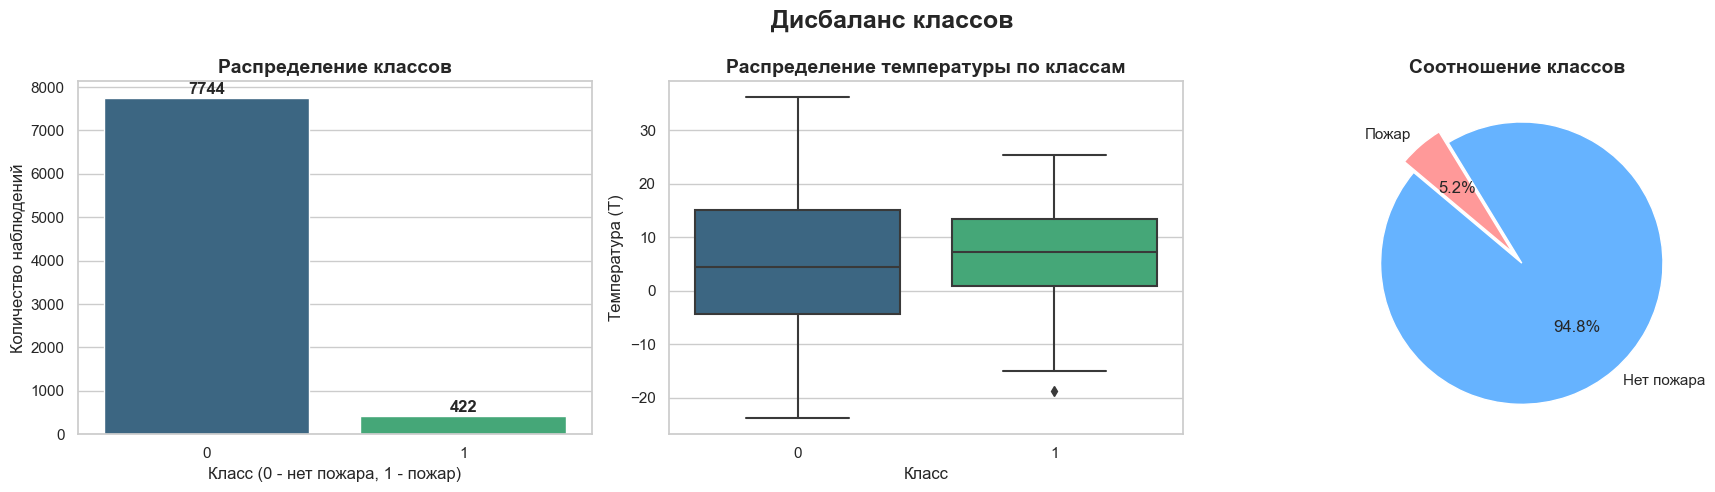

Используемые признаки: ['Dist_str', 'Dist_railw', 'Dist_car', 'T', 'Po', 'P', 'Pa', 'U', 'Ff', 'VV', 'Td']
Размер X после масштабирования: (8166, 11)
Целевая переменная: {0: 7744, 1: 422}
Исходные данные: Counter({0: 7744, 1: 422}) (всего: 8166)
RandomUnderSampler: Counter({0: 422, 1: 422}) (всего: 844)
NearMiss v1: Counter({0: 422, 1: 422}) (всего: 844)
NearMiss v2: Counter({0: 422, 1: 422}) (всего: 844)
NearMiss v3: Counter({1: 422, 0: 362}) (всего: 784)
RandomOverSampler: Counter({0: 7744, 1: 7744}) (всего: 15488)
SMOTE: Counter({0: 7744, 1: 7744}) (всего: 15488)


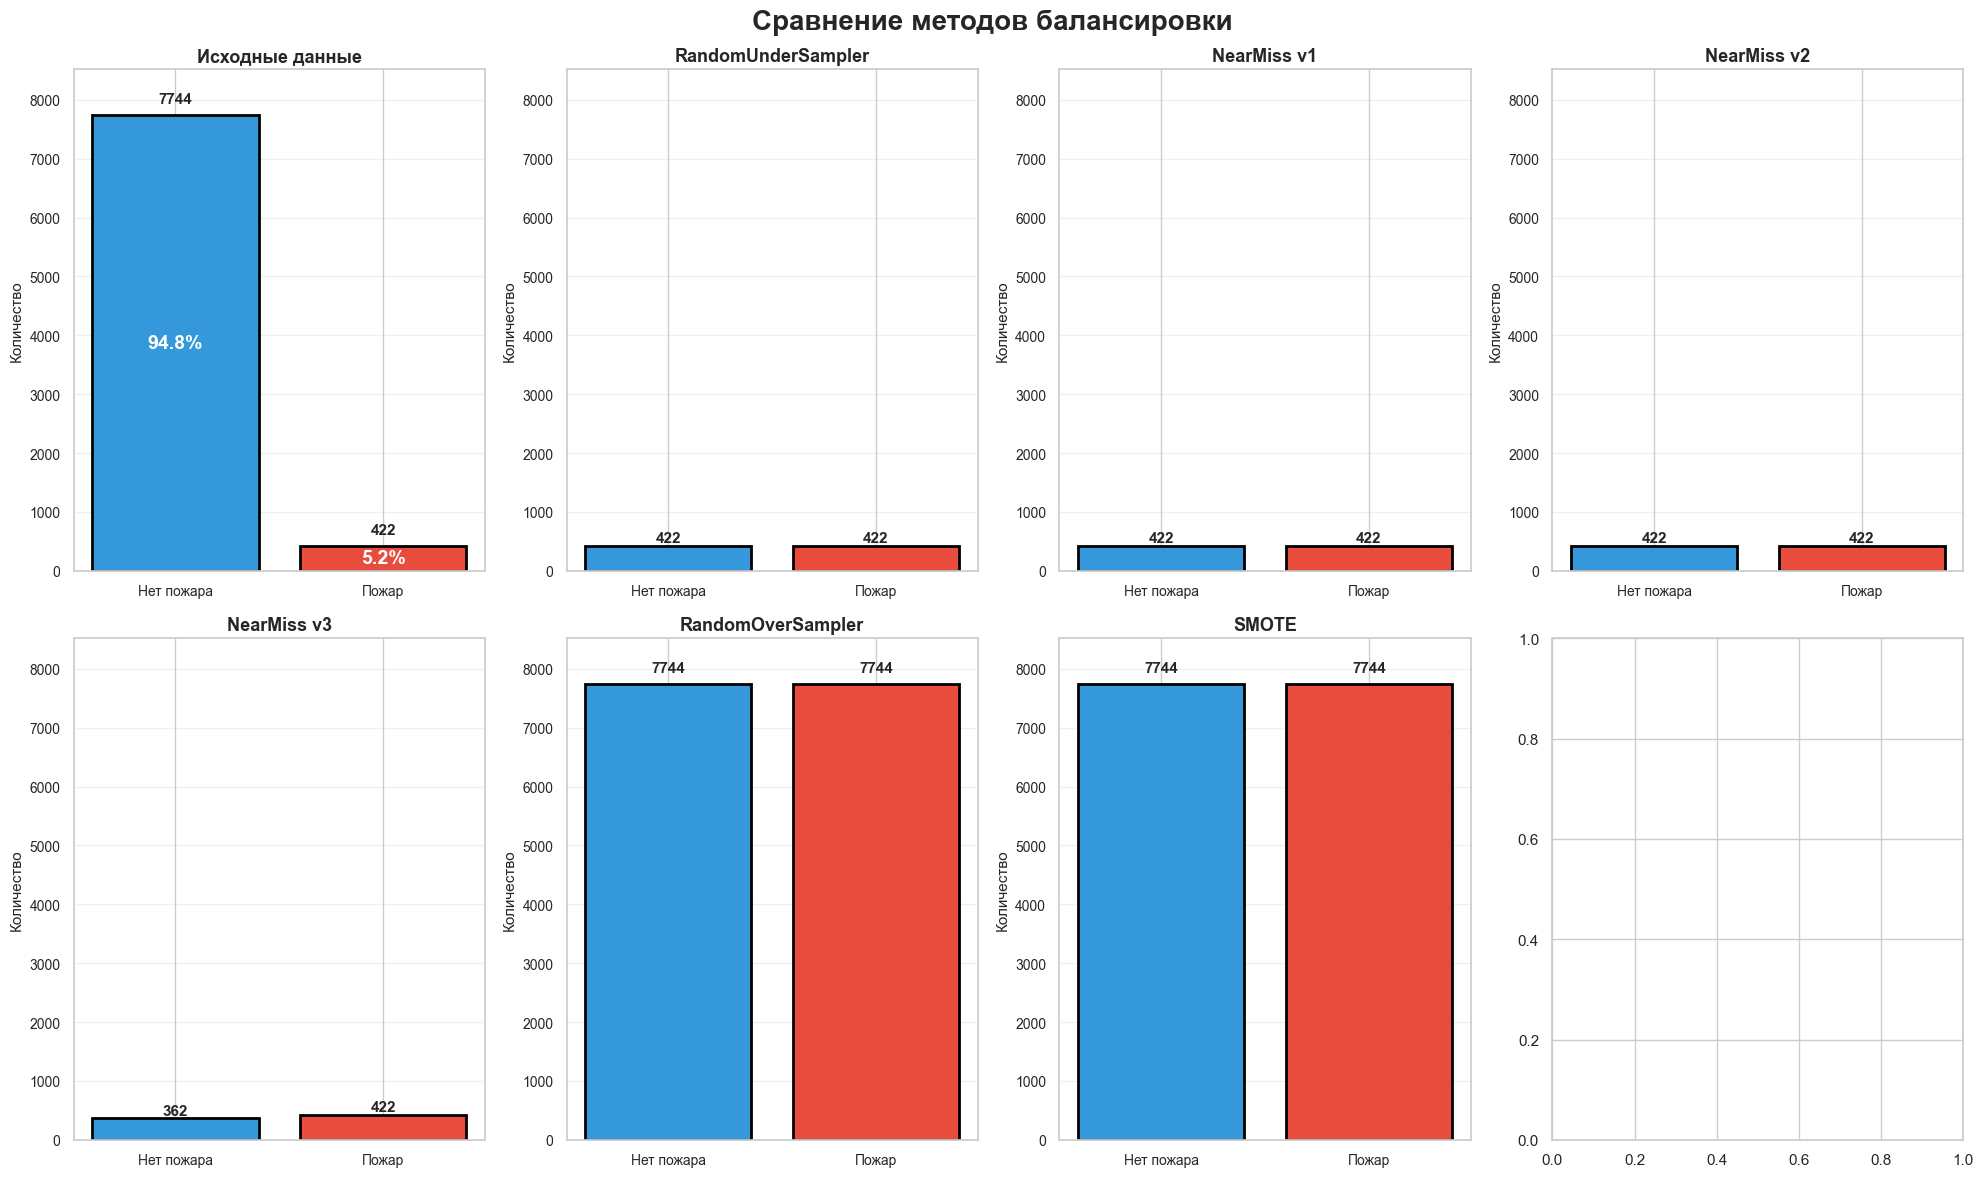

Визуализация по признакам: T и Td


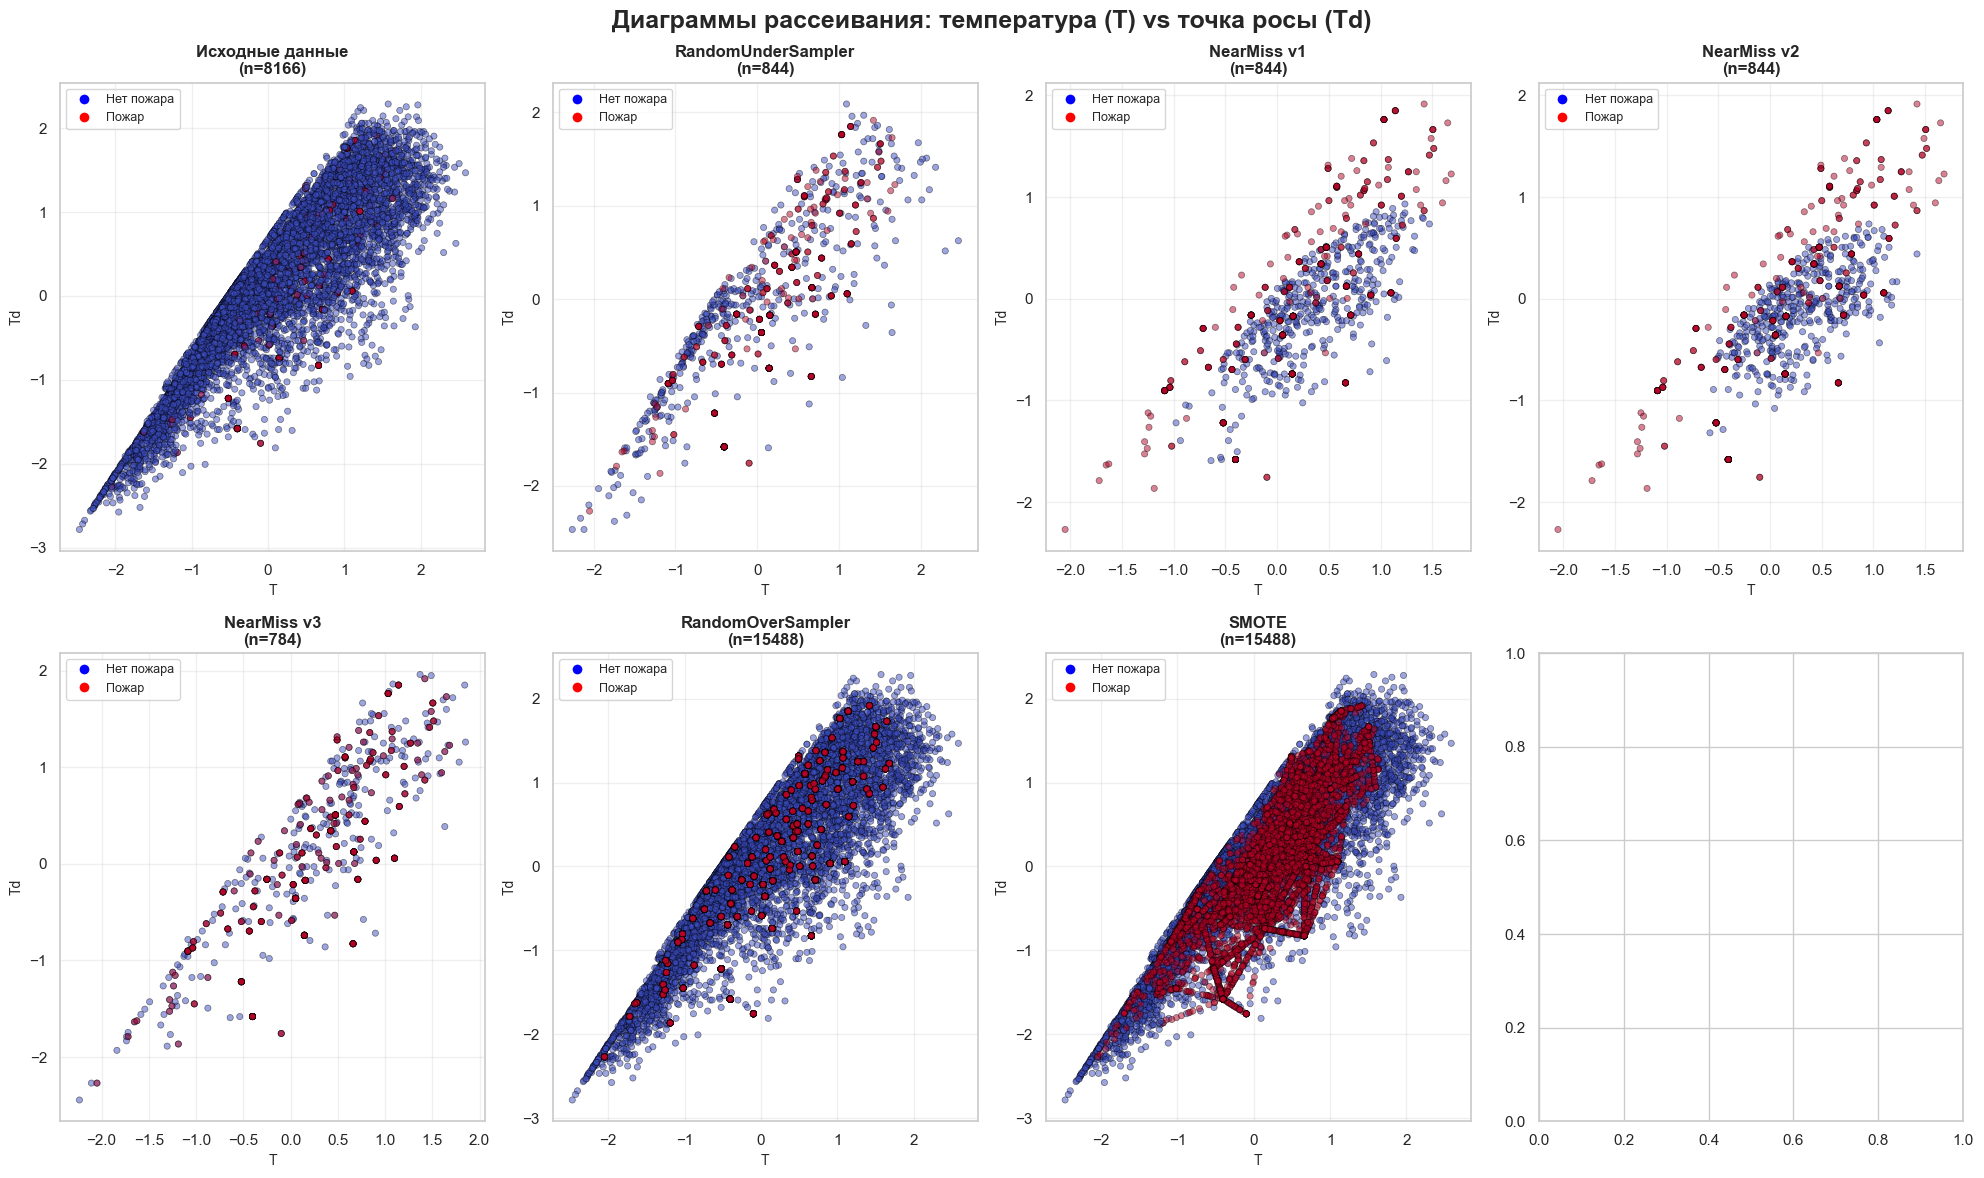

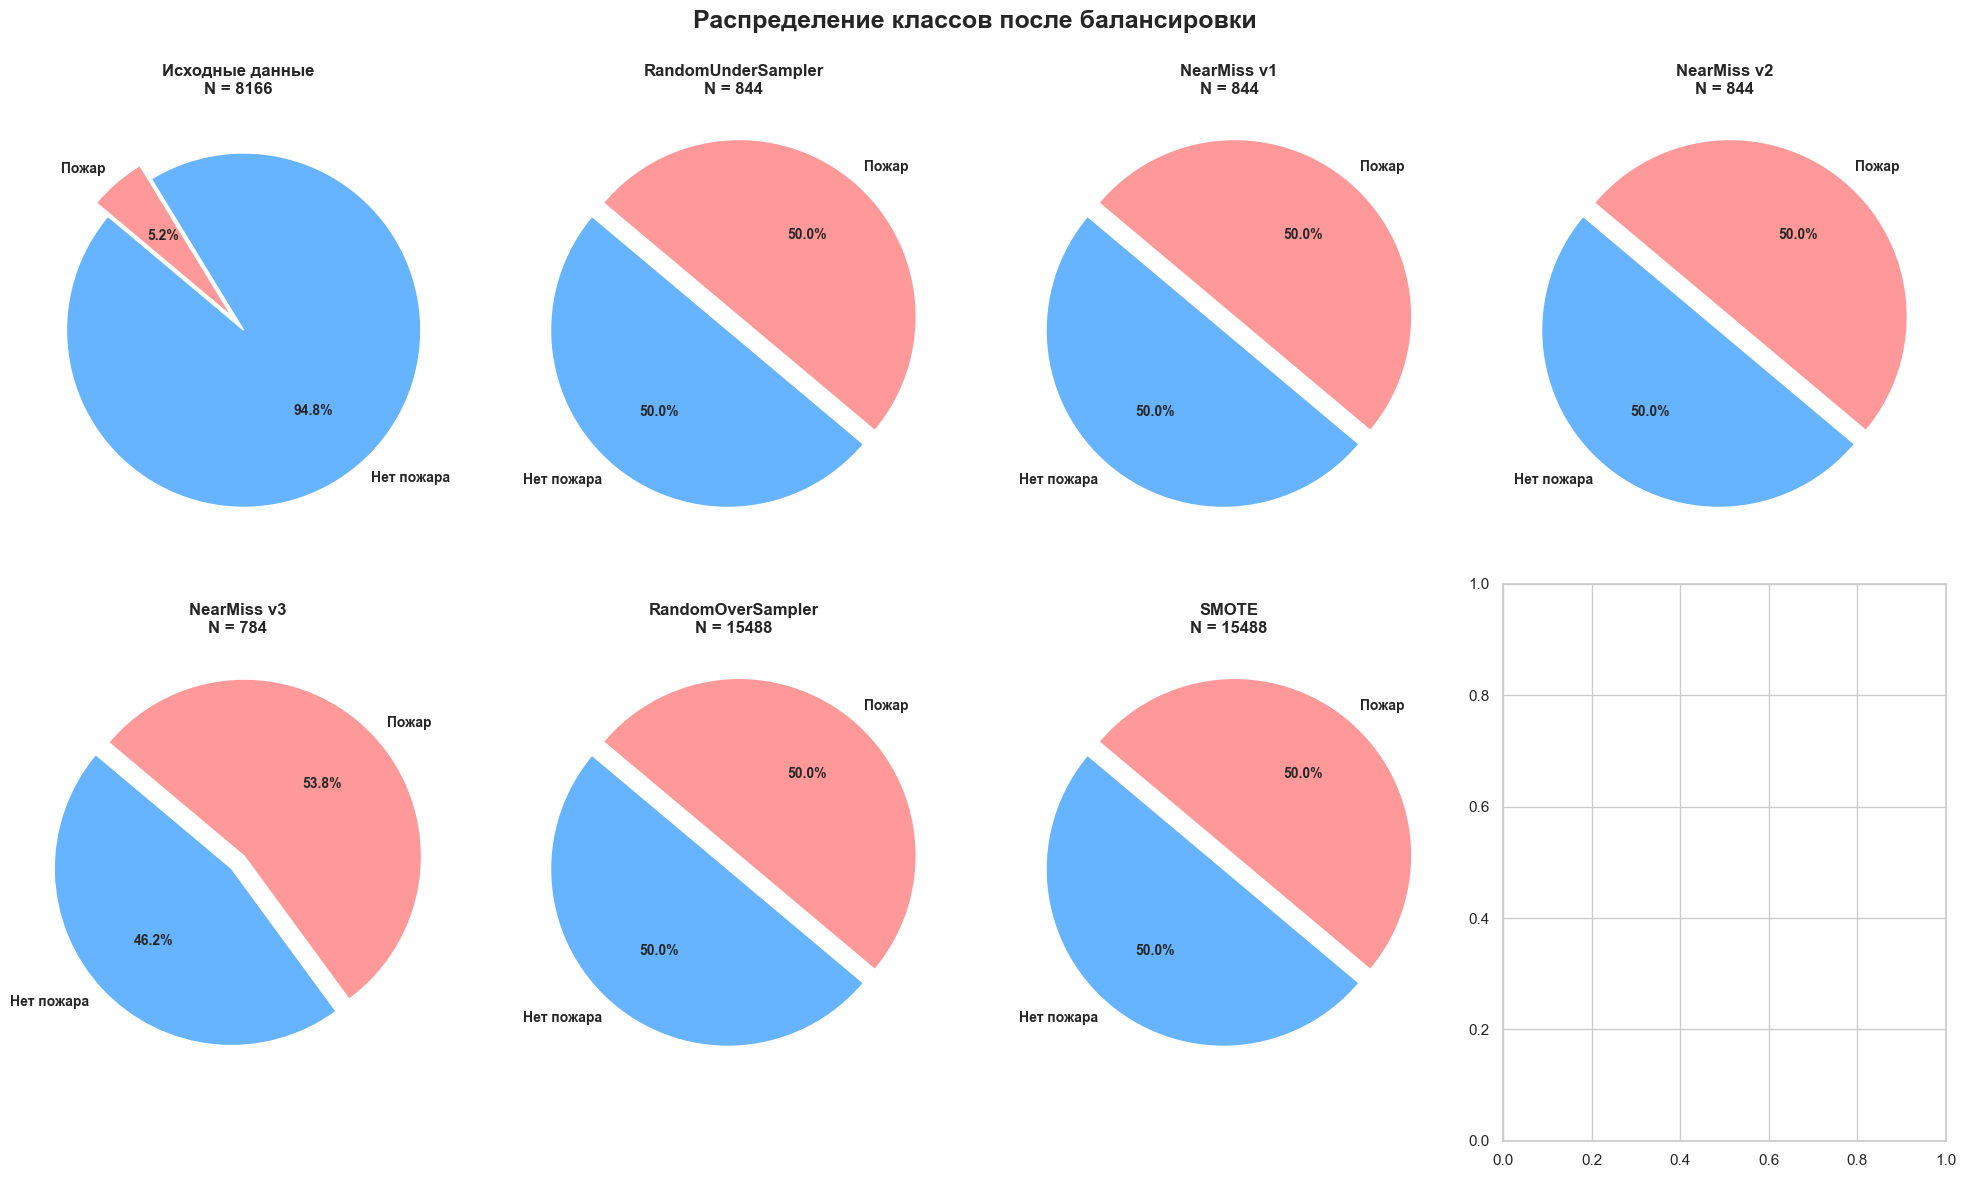

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.preprocessing import StandardScaler

from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.over_sampling import RandomOverSampler, SMOTE

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('10_fire_dataset_bin.xlsx', sheet_name='fire_dataset_bin')

df['target'] = (df['area'] > 0).astype(int)

print(f"Размер датасета: {df.shape[0]} записей")
print(f"Класс 0 (нет пожара): {(df['target'] == 0).sum()} ({(df['target'] == 0).mean()*100:.2f}%)")
print(f"Класс 1 (пожар): {(df['target'] == 1).sum()} ({(df['target'] == 1).mean()*100:.2f}%)")
print(f"Соотношение: {(df['target'] == 0).sum() / (df['target'] == 1).sum():.2f}:1")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='target', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Распределение классов', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Класс (0 - нет пожара, 1 - пожар)', fontsize=12)
axes[0].set_ylabel('Количество наблюдений', fontsize=12)

for i, v in enumerate(df['target'].value_counts().sort_index()):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold', fontsize=12)

sns.boxplot(x='target', y='T', data=df, palette='viridis', ax=axes[1])
axes[1].set_title('Распределение температуры по классам', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Класс', fontsize=12)
axes[1].set_ylabel('Температура (T)', fontsize=12)

counts = df['target'].value_counts()
colors = ['#66b3ff', '#ff9999']
axes[2].pie(counts, labels=['Нет пожара', 'Пожар'], autopct='%1.1f%%',
            colors=colors, startangle=140, explode=(0.05, 0.05))
axes[2].set_title('Соотношение классов', fontsize=14, fontweight='bold')

plt.suptitle('Дисбаланс классов', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('01_initial_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

exclude_cols = ['area', 'lon', 'lat']
feature_cols = [col for col in numeric_cols if col not in exclude_cols + ['target']]

X = df[feature_cols].copy()
y = df['target'].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print(f"Используемые признаки: {feature_cols}")
print(f"Размер X после масштабирования: {X_scaled.shape}")
print(f"Целевая переменная: {y.value_counts().to_dict()}")

methods = [
    ("Исходные данные", None, X_scaled, y),
    ("RandomUnderSampler", RandomUnderSampler(random_state=42), None, None),
    ("NearMiss v1", NearMiss(version=1, sampling_strategy='auto'), None, None),
    ("NearMiss v2", NearMiss(version=2, sampling_strategy='auto'), None, None),
    ("NearMiss v3", NearMiss(version=3, sampling_strategy='auto'), None, None),
    ("RandomOverSampler", RandomOverSampler(random_state=42), None, None),
    ("SMOTE", SMOTE(random_state=42), None, None),
]

results = {}
sampled_data = {}

for name, method, X_in, y_in in methods:
    if method is None:
        X_res, y_res = X_in, y_in
    else:
        X_res, y_res = method.fit_resample(X_scaled, y)
        sampled_data[name] = (X_res, y_res)
    
    results[name] = Counter(y_res)
    print(f"{name}: {results[name]} (всего: {len(y_res)})")

colors = ['#3498db', '#e74c3c']

fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, (name, method, X_in, y_in) in enumerate(methods):
    if idx >= 7:
        axes[idx].set_visible(False)
        continue
    
    ax = axes[idx]
    counts = results[name]
    
    bars = ax.bar(['Нет пожара', 'Пожар'], [counts[0], counts[1]], 
                  color=colors, edgecolor='black', linewidth=2)
    
    for bar, count in zip(bars, [counts[0], counts[1]]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts.values())*0.02,
                str(count), ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    if name == "Исходные данные":
        total = counts[0] + counts[1]
        ax.text(0, counts[0]/2, f'{counts[0]/total*100:.1f}%', 
                ha='center', va='center', color='white', fontweight='bold', fontsize=14)
        ax.text(1, counts[1]/2, f'{counts[1]/total*100:.1f}%', 
                ha='center', va='center', color='white', fontweight='bold', fontsize=14)
    
    ax.set_title(name, fontweight='bold', fontsize=13)
    ax.set_ylabel('Количество', fontsize=11)
    ax.set_ylim(0, max(results.values(), key=lambda x: max(x.values()))[0] * 1.1)
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='both', labelsize=10)

plt.suptitle('Сравнение методов балансировки', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig('02_methods_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

col_x = 'T'
col_y = 'Td'

if col_x not in X_scaled.columns:
    col_x = X_scaled.columns[0]
if col_y not in X_scaled.columns:
    col_y = X_scaled.columns[1]

print(f"Визуализация по признакам: {col_x} и {col_y}")

fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, (name, method, X_in, y_in) in enumerate(methods):
    if idx >= 7:
        axes[idx].set_visible(False)
        continue
    
    ax = axes[idx]
    
    if method is None:
        X_plot = X_scaled
        y_plot = y
    else:
        X_plot, y_plot = sampled_data[name]
    
    if isinstance(X_plot, np.ndarray):
        X_plot = pd.DataFrame(X_plot, columns=X_scaled.columns)
    
    ax.scatter(
        X_plot[col_x], X_plot[col_y],
        c=y_plot, cmap='coolwarm', alpha=0.5, s=20,
        edgecolors='black', linewidth=0.5
    )
    
    ax.set_title(f'{name}\n(n={len(y_plot)})', fontweight='bold', fontsize=12)
    ax.set_xlabel(col_x, fontsize=10)
    ax.set_ylabel(col_y, fontsize=10)
    ax.grid(True, alpha=0.3)
    
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Нет пожара'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Пожар')
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=9)

plt.suptitle('Диаграммы рассеивания: температура (T) vs точка росы (Td)', 
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('03_scatter_T_vs_Td.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.flatten()

colors_pie = ['#66b3ff', '#ff9999']
explode = (0.05, 0.05)

for idx, (name, method, X_in, y_in) in enumerate(methods):
    if idx >= 7:
        axes[idx].set_visible(False)
        continue
    
    ax = axes[idx]
    counts = results[name]
    
    ax.pie(
        [counts[0], counts[1]],
        labels=['Нет пожара', 'Пожар'],
        autopct='%1.1f%%',
        colors=colors_pie,
        startangle=140,
        explode=explode,
        textprops={'fontsize': 10, 'fontweight': 'bold'}
    )
    ax.set_title(f'{name}\nN = {len(y if method is None else sampled_data[name][1])}', 
                 fontweight='bold', fontsize=12)

plt.suptitle('Распределение классов после балансировки', 
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('04_pie_charts.png', dpi=150, bbox_inches='tight')
plt.show()

**Задание 4. Загрузить датасет проанализировать на наличие аномалий и выбросов, сделать визуализацию, сделать выводы.**
1. Датасет: 10_fire_dataset_bin.xlsx - данные о лесных пожарах.
2. Целевая переменная – area


Анализ датасета

Размер датасета: 8166 строк, 22 столбцов

Типы данных
float64           11
object             7
int64              3
datetime64[ns]     1
dtype: int64

Пропущенные значения
    Количество пропусков    Процент
WW                  5831  71.405829
           Unnamed: 0  area  lon  lat  Dist_str  Dist_railw  Dist_car     T  \
0 2017-09-24 10:00:00     0  0.0  0.0       0.0         0.0       0.0   9.4   
1 2017-09-24 13:00:00     0  0.0  0.0       0.0         0.0       0.0  11.7   
2 2017-09-24 16:00:00     0  0.0  0.0       0.0         0.0       0.0  11.6   
3 2017-09-24 19:00:00     0  0.0  0.0       0.0         0.0       0.0   7.7   
4 2017-09-24 22:00:00     0  0.0  0.0       0.0         0.0       0.0   6.1   

      Po      P  ...                                     DD  Ff             N  \
0  761.9  774.8  ...                Ветер, дующий с востока   2         100%.   
1  762.4  775.2  ...  Ветер, дующий с северо-северо-востока   3     70 – 80%.   
2  762.7  775.6  ...

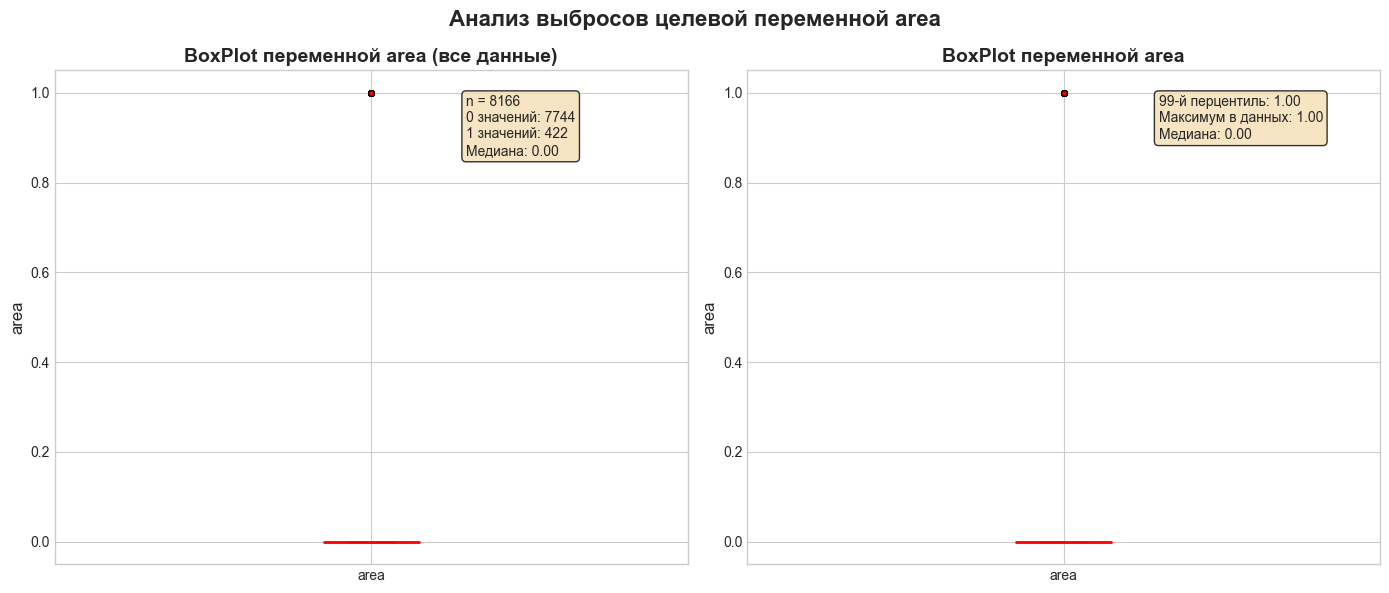


Выбранные переменные для анализа: ['Dist_str', 'Dist_railw', 'Dist_car', 'T', 'Po', 'P', 'Pa', 'U', 'Ff', 'VV']


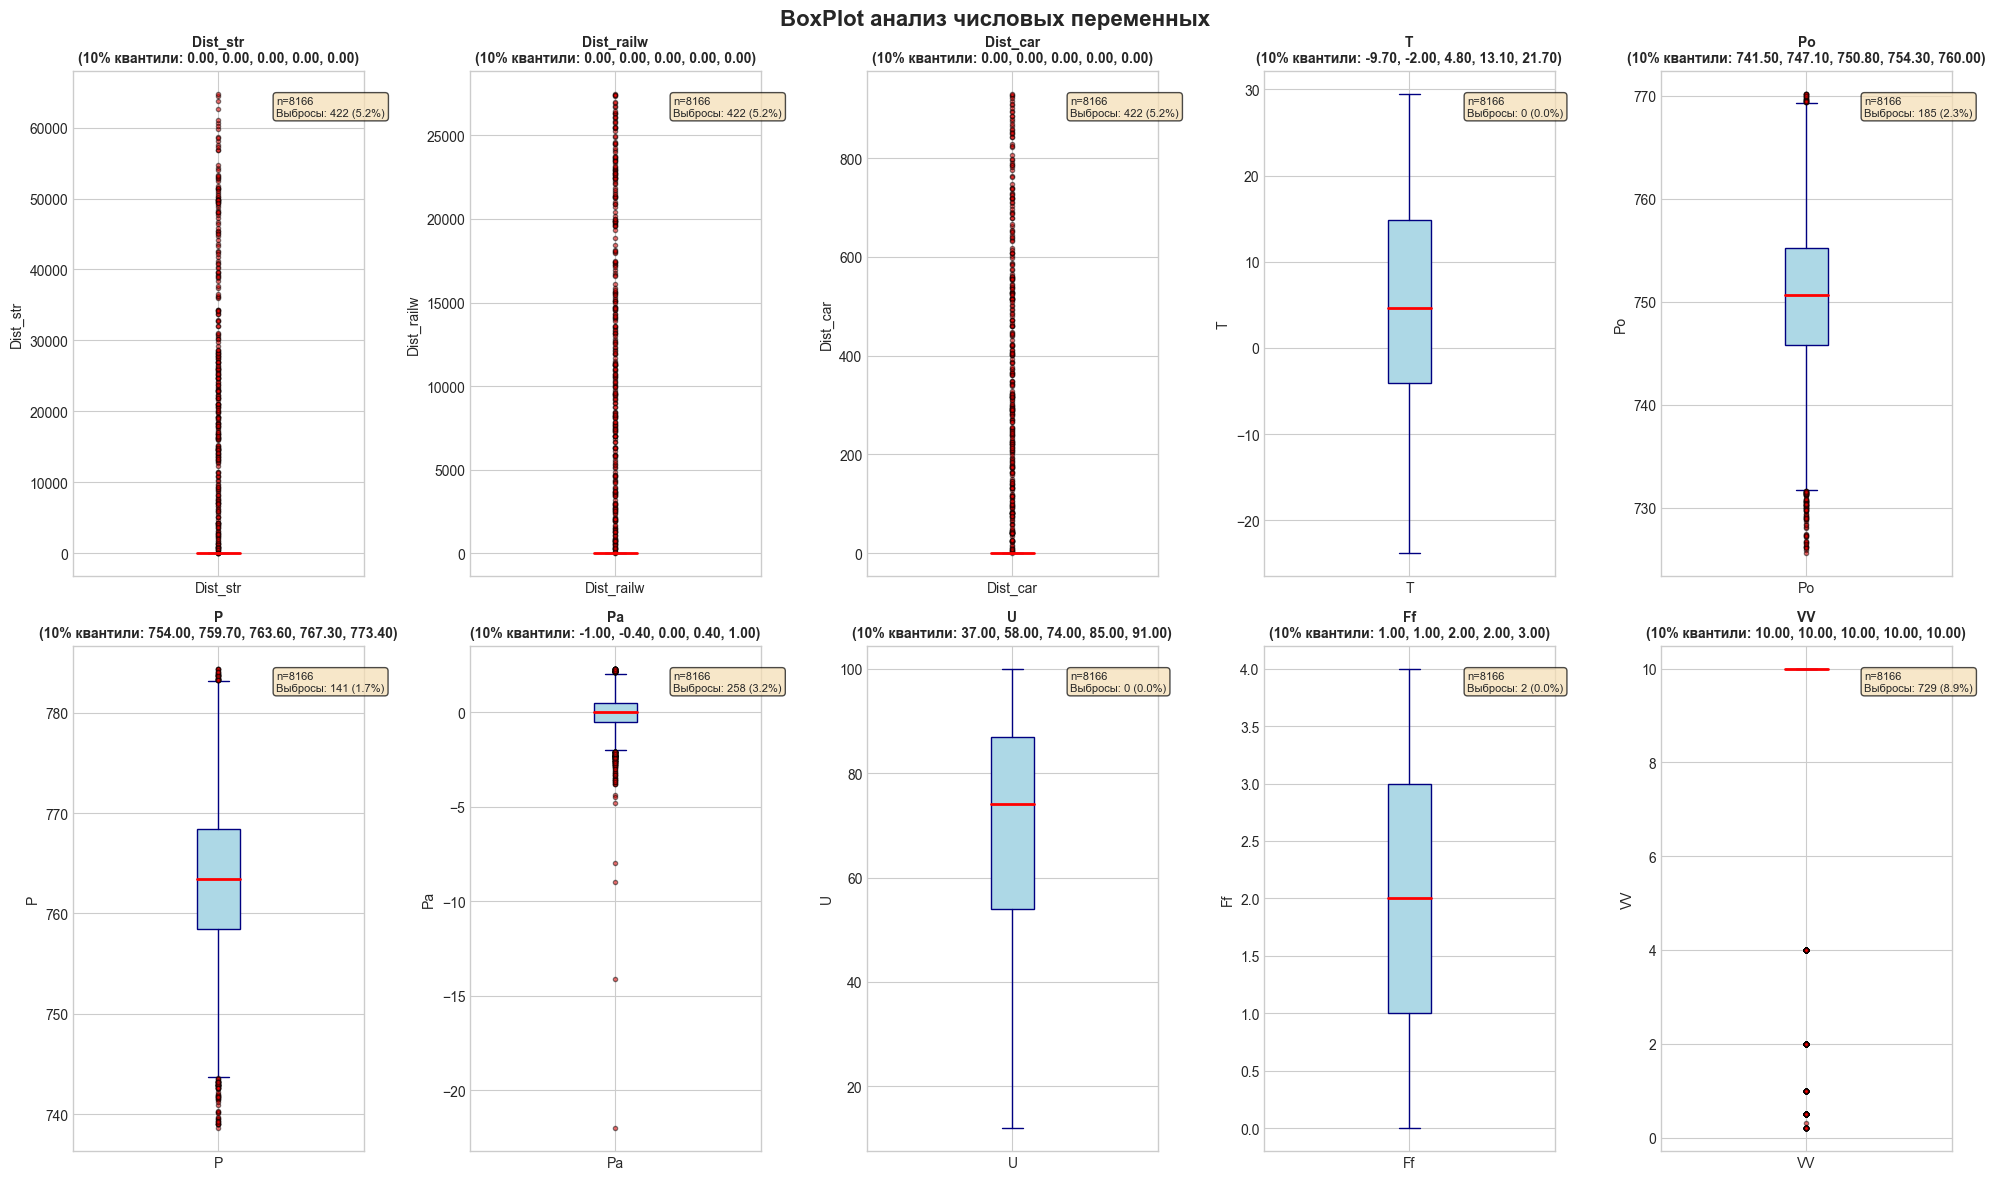

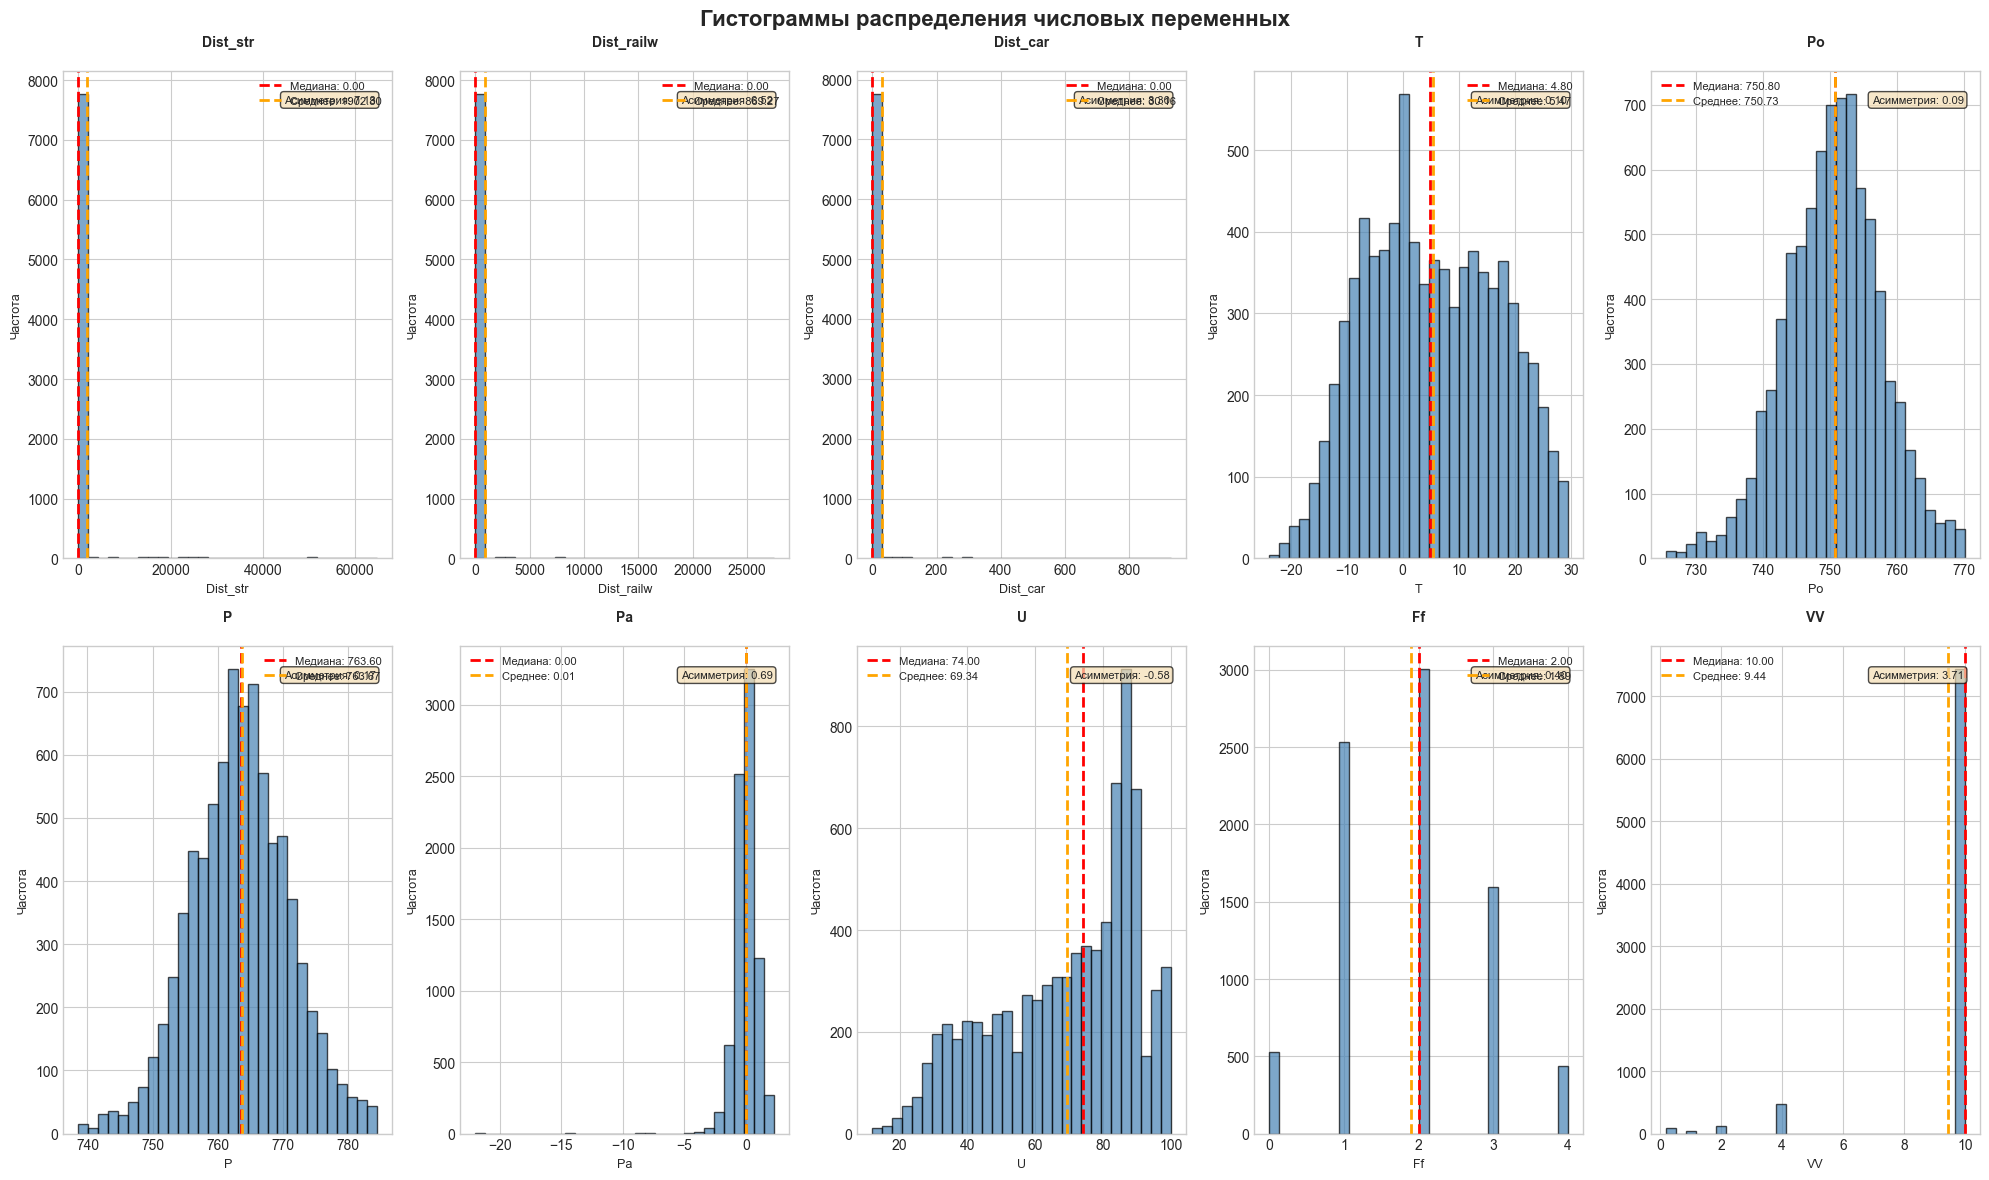

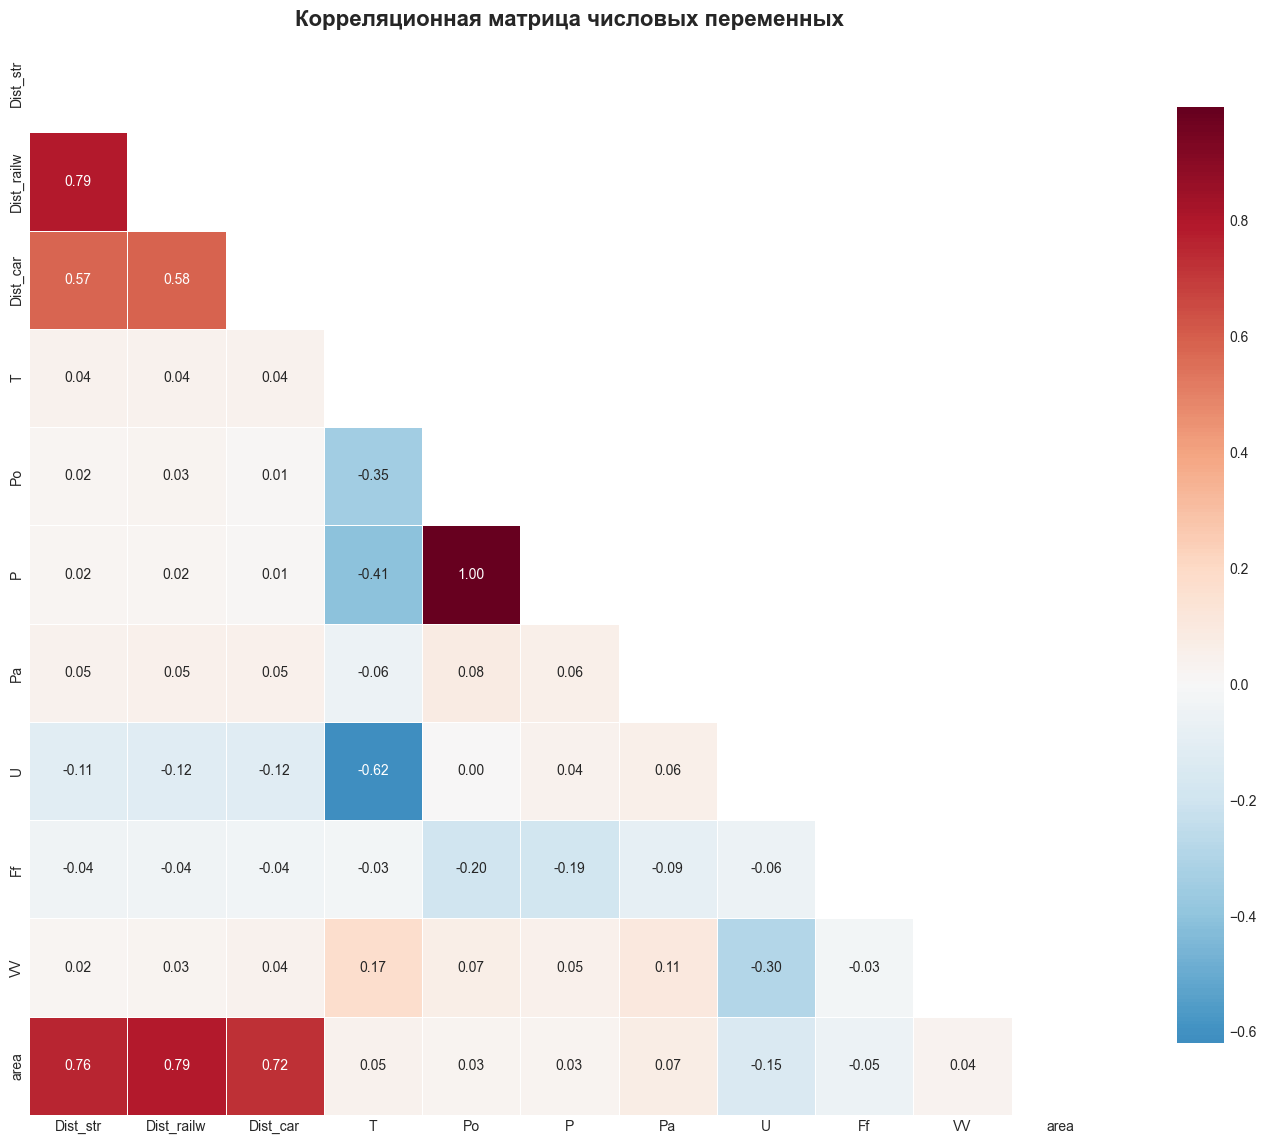


Корреляции с целевой переменной area
Dist_railw    0.788647
Dist_str      0.755936
Dist_car      0.724987
Pa            0.071566
T             0.045734
VV            0.035106
Po            0.030568
P             0.026632
Ff           -0.053972
U            -0.149108
Name: area, dtype: float64


In [6]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

file_path = '10_fire_dataset_bin.xlsx'
df = pd.read_excel(file_path, sheet_name='fire_dataset_bin')

print("Анализ датасета")
print(f"\nРазмер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\nТипы данных")
print(df.dtypes.value_counts())
print("\nПропущенные значения")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Количество пропусков': missing, 'Процент': missing_pct})
print(missing_df[missing_df['Количество пропусков'] > 0])
print(df.head())

print("\nСтатистика числовых признаков")
print(df.describe())

if 'area' in df.columns:
    print("Анализ целевой переменной - area")
    area_data = df['area'].dropna()
    print(f"\nКоличество наблюдений: {len(area_data)}")
    print(f"Количество уникальных значений: {area_data.nunique()}")
    print(f"Уникальные значения: {sorted(area_data.unique())}")
    
    print("\nСтатистика area")
    print(f"Среднее: {area_data.mean():.4f}")
    print(f"Медиана: {area_data.median():.4f}")
    print(f"Мода: {area_data.mode().tolist()}")
    print(f"Стандартное отклонение: {area_data.std():.4f}")
    print(f"Минимум: {area_data.min():.4f}")
    print(f"Максимум: {area_data.max():.4f}")
    print(f"25-й перцентиль: {area_data.quantile(0.25):.4f}")
    print(f"75-й перцентиль: {area_data.quantile(0.75):.4f}")
    print(f"IQR: {area_data.quantile(0.75) - area_data.quantile(0.25):.4f}")
    
    print("\nРаспределение значений area")
    print(f"Значения == 0: {(area_data == 0).sum()} ({((area_data == 0).sum()/len(area_data))*100:.1f}%)")
    print(f"Значения == 1: {(area_data == 1).sum()} ({((area_data == 1).sum()/len(area_data))*100:.1f}%)")
    print(f"Другие значения: {(area_data > 1).sum()} ({((area_data > 1).sum()/len(area_data))*100:.1f}%)")    

    Q1 = area_data.quantile(0.25)
    Q3 = area_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound_iqr = Q1 - 1.5 * IQR
    upper_bound_iqr = Q3 + 1.5 * IQR
    outliers_iqr = area_data[(area_data < lower_bound_iqr) | (area_data > upper_bound_iqr)]
    
    print(f"\n--- Выбросы по методу IQR (1.5*IQR) ---")
    print(f"Нижняя граница: {lower_bound_iqr:.4f}")
    print(f"Верхняя граница: {upper_bound_iqr:.4f}")
    print(f"Количество выбросов: {len(outliers_iqr)} ({len(outliers_iqr)/len(area_data)*100:.1f}%)")
    print(f"Значения-выбросы: {sorted(outliers_iqr.unique())}")
    
    z_scores = np.abs(stats.zscore(area_data))
    outliers_zscore = area_data[z_scores > 3]
    print(f"\n--- Выбросы по методу Z-score (|z| > 3) ---")
    print(f"Количество выбросов: {len(outliers_zscore)} ({len(outliers_zscore)/len(area_data)*100:.1f}%)")
    print(f"Значения-выбросы: {sorted(outliers_zscore.unique())}")
    
    median = area_data.median()
    mad = np.median(np.abs(area_data - median))
    modified_z_scores = 0.6745 * (area_data - median) / mad
    outliers_modified_z = area_data[np.abs(modified_z_scores) > 3.5]
    print(f"\n--- Выбросы по методу модифицированного Z-score (|M| > 3.5) ---")
    print(f"Количество выбросов: {len(outliers_modified_z)} ({len(outliers_modified_z)/len(area_data)*100:.1f}%)")
    
print("Анализ числовых переменных")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['area', 'lon', 'lat']
numeric_cols_analysis = [col for col in numeric_cols if col not in exclude_cols]
print(f"\nАнализируемые числовые признаки: {numeric_cols_analysis}")

outliers_summary = {}

for col in numeric_cols_analysis:
    data = df[col].dropna()
    if len(data) > 0 and data.nunique() > 1:
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers_iqr = data[(data < lower_bound) | (data > upper_bound)]
        
        z_scores = np.abs(stats.zscore(data))
        outliers_z = data[z_scores > 3]
        
        outliers_summary[col] = {
            'min': data.min(),
            'max': data.max(),
            'mean': data.mean(),
            'median': data.median(),
            'std': data.std(),
            'outliers_iqr_count': len(outliers_iqr),
            'outliers_iqr_pct': len(outliers_iqr)/len(data)*100,
            'outliers_z_count': len(outliers_z),
            'outliers_z_pct': len(outliers_z)/len(data)*100,
            'unique_values': data.nunique()
        }

outliers_df = pd.DataFrame(outliers_summary).T
print("\nСводка выбросов по числовым переменным")
print(outliers_df[['min', 'max', 'mean', 'median', 'std', 'outliers_iqr_count', 'outliers_iqr_pct', 'outliers_z_count', 'outliers_z_pct']].round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax1 = axes[0]
area_data_filtered = df[df['area'] <= df['area'].quantile(0.99)]['area'].dropna()
bp1 = ax1.boxplot(df['area'].dropna(), patch_artist=True, 
                   boxprops=dict(facecolor='lightblue', color='darkblue'),
                   whiskerprops=dict(color='darkblue'),
                   capprops=dict(color='darkblue'),
                   medianprops=dict(color='red', linewidth=2),
                   flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))
ax1.set_title('BoxPlot переменной area (все данные)', fontsize=14, fontweight='bold')
ax1.set_ylabel('area', fontsize=12)
ax1.set_xticklabels(['area'])

stats_text = f'n = {len(df["area"].dropna())}\n'
stats_text += f'0 значений: {(df["area"] == 0).sum()}\n'
stats_text += f'1 значений: {(df["area"] == 1).sum()}\n'
stats_text += f'Медиана: {df["area"].median():.2f}'
ax1.text(0.65, 0.95, stats_text, transform=ax1.transAxes, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax2 = axes[1]
area_clean = df[(df['area'] <= df['area'].quantile(0.99))]['area'].dropna()
bp2 = ax2.boxplot(area_clean, patch_artist=True,
                   boxprops=dict(facecolor='lightgreen', color='darkgreen'),
                   whiskerprops=dict(color='darkgreen'),
                   capprops=dict(color='darkgreen'),
                   medianprops=dict(color='red', linewidth=2),
                   flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))
ax2.set_title('BoxPlot переменной area', fontsize=14, fontweight='bold')
ax2.set_ylabel('area', fontsize=12)
ax2.set_xticklabels(['area'])

stats_text2 = f'99-й перцентиль: {df["area"].quantile(0.99):.2f}\n'
stats_text2 += f'Максимум в данных: {area_clean.max():.2f}\n'
stats_text2 += f'Медиана: {area_clean.median():.2f}'
ax2.text(0.65, 0.95, stats_text2, transform=ax2.transAxes, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Анализ выбросов целевой переменной area', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

candidate_cols = []
for col in numeric_cols_analysis:
    if df[col].nunique() > 1 and df[col].nunique() < 1000:  
        candidate_cols.append(col)

selected_cols = candidate_cols[:10]
if len(selected_cols) < 10:
    additional_cols = [col for col in numeric_cols_analysis if col not in selected_cols]
    selected_cols.extend(additional_cols[:10-len(selected_cols)])

print(f"\nВыбранные переменные для анализа: {selected_cols}")

fig, axes = plt.subplots(2, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(selected_cols[:10]):
    ax = axes[i]
    data = df[col].dropna()
    upper_limit = data.quantile(0.99)
    data_trimmed = data[data <= upper_limit]
    
    bp = ax.boxplot(data_trimmed, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', color='navy'),
                     whiskerprops=dict(color='navy'),
                     capprops=dict(color='navy'),
                     medianprops=dict(color='red', linewidth=2),
                     flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.5))
    
    quantiles = data.quantile([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
    
    ax.set_title(f'{col}\n(10% квантили: {quantiles.iloc[0]:.2f}, {quantiles.iloc[2]:.2f}, {quantiles.iloc[4]:.2f}, {quantiles.iloc[6]:.2f}, {quantiles.iloc[8]:.2f})', 
                 fontsize=10, fontweight='bold')
    ax.set_ylabel(col, fontsize=10)
    ax.set_xticklabels([col])
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    outliers_iqr = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
    outliers_pct = len(outliers_iqr)/len(data)*100
    
    stats_text = f'n={len(data)}\nВыбросы: {len(outliers_iqr)} ({outliers_pct:.1f}%)'
    ax.text(0.7, 0.95, stats_text, transform=ax.transAxes, 
            verticalalignment='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.suptitle('BoxPlot анализ числовых переменных', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(selected_cols[:10]):
    ax = axes[i]
    data = df[col].dropna()
    upper_limit = data.quantile(0.99)
    data_hist = data[data <= upper_limit]
    
    ax.hist(data_hist, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=2, label=f'Медиана: {data.median():.2f}')
    ax.axvline(data.mean(), color='orange', linestyle='--', linewidth=2, label=f'Среднее: {data.mean():.2f}')
    ax.set_title(f'{col}\n', fontsize=10, fontweight='bold')
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('Частота', fontsize=9)
    ax.legend(fontsize=8)
    
    skewness = data.skew()
    ax.text(0.95, 0.95, f'Асимметрия: {skewness:.2f}', transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='right', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.suptitle('Гистограммы распределения числовых переменных', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 12))
numeric_data = df[selected_cols[:10] + ['area']].select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица числовых переменных', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nКорреляции с целевой переменной area")
corr_with_area = corr_matrix['area'].drop('area').sort_values(ascending=False)
print(corr_with_area)


**Задание 5 - Выполнить парсинг двух страниц с сайта https://zakupki.gov.ru/ (либо другой сайт)  по каждой закупке спарсить номер закупки, дату размещения, обновления и окончание подачи заявок, начальную цену контракта. Данные сохранить в pandas датафрейм и в формат csv.**

In [6]:
import requests
from bs4 import BeautifulSoup

def parse_books_page(page_num):
    url = f'http://books.toscrape.com/catalogue/page-{page_num}.html'
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    
    books = []
    for book in soup.find_all('article', class_='product_pod'):
        title = book.find('h3').find('a')['title']
        price = book.find('p', class_='price_color').text
        rating = book.find('p', class_='star-rating')['class'][1]
        
        purchase = {
            'purchase_number': len(books) + 1,           
            'product_name': title,                       
            'contract_price': price,                     
            'category': 'Books',                        
            'supplier_rating': rating,                   
            'publish_date': 'March 2024',                 
            'submission_deadline': 'April 2024'       
        }
        books.append(purchase)
    
    return books

all_data = []
for page in [1, 2]:
    print(f"\nПарсинг страницы {page}")
    page_data = parse_books_page(page)
    all_data.extend(page_data)
    print(f"  Найдено записей: {len(page_data)}")

df = pd.DataFrame(all_data)
df.columns = ['Номер закупки', 'Наименование товара', 'Начальная цена контракта', 
              'Категория', 'Рейтинг', 'Дата размещения', 'Окончание подачи заявок']

print(f"\n Всего собрано: {len(df)} записей")
print(df.head())
df.to_csv('parsed_purchases.csv', index=False, encoding='utf-8-sig')
print("Статистика")
print(f"Всего: {len(df)}")
print(f"Уникальных товаров: {df['Наименование товара'].nunique()}")
print(f"Диапазон цен: от {df['Начальная цена контракта'].min()} до {df['Начальная цена контракта'].max()}")
print(f"Распределение по рейтингу:")
print(df['Рейтинг'].value_counts())


Парсинг страницы 1
  Найдено записей: 20

Парсинг страницы 2
  Найдено записей: 20

 Всего собрано: 40 записей
   Номер закупки                    Наименование товара  \
0              1                   A Light in the Attic   
1              2                     Tipping the Velvet   
2              3                             Soumission   
3              4                          Sharp Objects   
4              5  Sapiens: A Brief History of Humankind   

  Начальная цена контракта Категория Рейтинг Дата размещения  \
0                  Â£51.77     Books   Three      March 2024   
1                  Â£53.74     Books     One      March 2024   
2                  Â£50.10     Books     One      March 2024   
3                  Â£47.82     Books    Four      March 2024   
4                  Â£54.23     Books    Five      March 2024   

  Окончание подачи заявок  
0              April 2024  
1              April 2024  
2              April 2024  
3              April 2024  
4       

**Задание 6. Загрузить и собрать датасет, определить категориальные признаки, применить методы LabelEncoder, One Hot Encoding, написать выводы.**
1. Датасет: 11_automobiles.rar
2. Описывает классические автомобили


In [7]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
column_names = [
    'symboling', 'normalized_losses', 'make', 'fuel_type', 'aspiration',
    'num_of_doors', 'body_style', 'drive_wheels', 'engine_location',
    'wheel_base', 'length', 'width', 'height', 'curb_weight',
    'engine_type', 'num_of_cylinders', 'engine_size', 'fuel_system',
    'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm',
    'city_mpg', 'highway_mpg', 'price'
]
df = pd.read_csv('imports-85.data', names=column_names, na_values='?')

print(f"\n Данные загружены: {df.shape[0]} строк, {df.shape[1]} колонок")
print("Анализ данных")
print(df.head())
print(df.dtypes)
print("\nСтатистика по пропускам:")
print(df.isnull().sum()[df.isnull().sum() > 0])
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n Кол-во категориальных признаков ({len(categorical_cols)}):")
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f" {col}: {unique_count} уникальных значений")
    print(f"  {df[col].dropna().unique()[:3].tolist()}")

print("Обработка пропусков")
df_clean = df.dropna(subset=categorical_cols)
print(f"После удаления пропусков: {df_clean.shape[0]} строк")

print("LabelEncoder")
df_label_encoded = df_clean.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_label_encoded[col + '_encoded'] = le.fit_transform(df_label_encoded[col].astype(str))
    label_encoders[col] = le
    print(f"\n{col}:")
    print(f"  Исходные: {df_clean[col].unique()[:3].tolist()}")
    print(f"  Закодированные: {df_label_encoded[col + '_encoded'].unique()[:3].tolist()}")

print("\nРезультат LabelEncoder:")
print(df_label_encoded[categorical_cols + [col + '_encoded' for col in categorical_cols]].head())


print("OneHotEncoder")
df_for_ohe = df_clean[categorical_cols].copy()
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = ohe.fit_transform(df_for_ohe)
feature_names = ohe.get_feature_names_out(categorical_cols)
df_ohe = pd.DataFrame(encoded_array, columns=feature_names, index=df_clean.index)

print(f"\nРазмер после OneHotEncoding: {df_ohe.shape}")
print(f"Было колонок: {len(categorical_cols)}, стало: {df_ohe.shape[1]}")
print(df_ohe.iloc[:5, :10])
print("Итоговый датасет")
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in categorical_cols]
df_final = pd.concat([df_clean[numeric_cols], df_ohe], axis=1)
print(f"Итоговый размер: {df_final.shape}")
print(f"Числовых признаков: {len(numeric_cols)}")
print(f"Бинарных признаков (OneHot): {df_ohe.shape[1]}")

df_label_encoded.to_csv('automobiles_label_encoded.csv', index=False, encoding='utf-8-sig')
df_ohe.to_csv('automobiles_onehot_encoded.csv', index=False, encoding='utf-8-sig')
df_final.to_csv('automobiles_final_encoded.csv', index=False, encoding='utf-8-sig')
print(f"Исходный датасет: {df_clean.shape[1]} колонок")
print(f"После LabelEncoder: {df_label_encoded.shape[1]} колонок")
print(f"После OneHotEncoder: {df_final.shape[1]} колонок")
print(f"Увеличение размерности: {df_final.shape[1] - df_clean.shape[1]} новых колонок")


 Данные загружены: 205 строк, 26 колонок
Анализ данных
   symboling  normalized_losses         make fuel_type aspiration  \
0          3                NaN  alfa-romero       gas        std   
1          3                NaN  alfa-romero       gas        std   
2          1                NaN  alfa-romero       gas        std   
3          2              164.0         audi       gas        std   
4          2              164.0         audi       gas        std   

  num_of_doors   body_style drive_wheels engine_location  wheel_base  ...  \
0          two  convertible          rwd           front        88.6  ...   
1          two  convertible          rwd           front        88.6  ...   
2          two    hatchback          rwd           front        94.5  ...   
3         four        sedan          fwd           front        99.8  ...   
4         four        sedan          4wd           front        99.4  ...   

   engine_size  fuel_system  bore  stroke compression_ratio horsep